In [16]:
import pandas as pd
import numpy as np
from keras.layers import Dense
from keras import Sequential

In [13]:
import matplotlib.pyplot as plt
import tensorflow
import keras
from sklearn.model_selection import train_test_split

In [55]:
from keras.layers import BatchNormalization

In [3]:
from sklearn.datasets import make_circles

In [106]:
X,y= make_circles(n_samples=100,noise=0.1, random_state=25)

In [107]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [108]:
X_train

array([[-0.67544621, -0.13136222],
       [-0.71780236, -0.75515294],
       [ 0.74742896,  0.38553826],
       [-0.63814653,  0.73179902],
       [-0.70803622, -0.67583323],
       [ 0.29628345, -0.69116763],
       [-0.61158664,  0.83275359],
       [-0.18482027,  1.04442761],
       [ 0.79806143, -0.13396905],
       [ 0.49515809, -0.54806955],
       [-0.25642854,  0.66267371],
       [ 0.14043131,  0.90289852],
       [ 0.26949162, -0.97216674],
       [-1.09588305,  0.05079853],
       [ 0.67084859, -0.67654745],
       [ 0.65874639,  0.59942299],
       [-0.87124359,  0.0563586 ],
       [-0.89051094, -0.25941273],
       [-0.1653406 , -0.99875727],
       [ 0.70632128, -0.49239648],
       [-0.54984353, -0.32466246],
       [ 0.75473994,  0.66531474],
       [ 0.06384561, -0.89781003],
       [ 0.25539923,  0.74095081],
       [-0.85361463, -0.08268344],
       [ 0.84253738, -0.44596579],
       [ 0.96986061, -0.65629107],
       [-0.8139056 ,  0.39135615],
       [ 0.73675635,

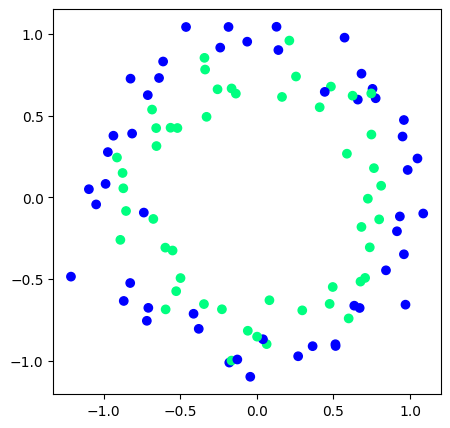

In [109]:
plt.figure(figsize=(5,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter"); 

In [110]:
from keras.callbacks import EarlyStopping

In [115]:
model = Sequential()

In [116]:
callback = EarlyStopping(
    monitor = "val_loss", 
    min_delta = 0.000001,
    patience=20,
    mode = "auto",
    verbose=1,
    baseline = None, 
    restore_best_weights = False
)

In [117]:
model.add(Dense(256,activation="relu",input_dim=2)) ;
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

In [118]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=['accuracy'])

In [119]:
hist = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=200,verbose=1,callbacks=callback)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.5227 - loss: 1.0009 - val_accuracy: 0.4000 - val_loss: 0.6912
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5516 - loss: 0.7511 - val_accuracy: 0.5500 - val_loss: 0.6928
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5039 - loss: 0.7294 - val_accuracy: 0.5500 - val_loss: 0.6928
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5984 - loss: 0.6749 - val_accuracy: 0.4500 - val_loss: 0.6938
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5938 - loss: 0.6834 - val_accuracy: 0.4500 - val_loss: 0.6937
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6734 - loss: 0.6369 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6789 - loss: 0.6391 - val_accuracy: 0.4500 - val_loss: 0.6925
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7102 - loss: 0.5925 - val_accuracy: 0.4000 - val_loss

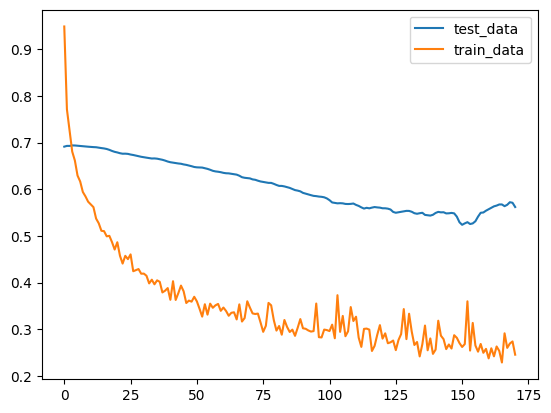

In [120]:
plt.plot(hist.history['val_loss'],label='test_data')
plt.plot(hist.history['loss'],label="train_data")
plt.legend()
plt.show()

In [121]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 908us/step


<Axes: >

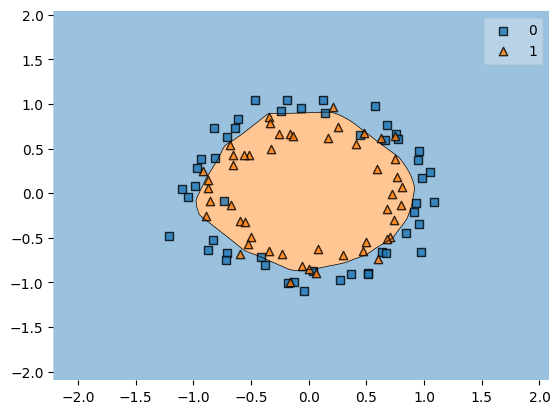

In [123]:
plot_decision_regions(X,y,model)

## This model is gettng better accuracy after adding the batch normalization

## BN is better to implement on every network .But you can include or exclude the BN on layer by layer 